# Example notebook for ABM analyses

This notebook provides example code to extract data from and conduct analyses on ABM outputs, and is also designed to be a tutorial to familarize users with the ABM, its outputs, and the types of analyses we do. The simulation data needed for this notebook to run properly is not currently uploaded to GitHub, but will be in the future. A different notebook contains the complete code needed to reproduce the figures in [PAPER]. 

The installation of functions & constants for the analysis will eventually be done via package installation, but is not currently configured for such a set-up.

In [1]:
import sys
import os

# Import custom functions (will convert to package install @ later date
sys.path.append('/project2/sfinley_500/tking/abm_testing/breast_cancer/python/src')
from analyzeABM import *

# Set this path to wherever the simulation data is located
path_to_simulations = "/project2/sfinley_500/tking/abm_testing/breast_cancer" 

## Retrieving and analyzing data from a single metastasis

In [2]:
# Let's look at one met
met = 107

# This is the path to all non-tx results for this met
path_notx = os.path.join(path_to_simulations, "simulations_may2026", f"mIHC_{met}")

# This is the path to all tx results for this met
path_tx = os.path.join(path_to_simulations, "simulations_may2026", f"mIHC_{met}_tx")

# Now, we can read in all the data for each case
met_notx = retrieve_ts(path_notx, num_replicates=25)
met_tx = retrieve_ts(path_tx, num_replicates=25)

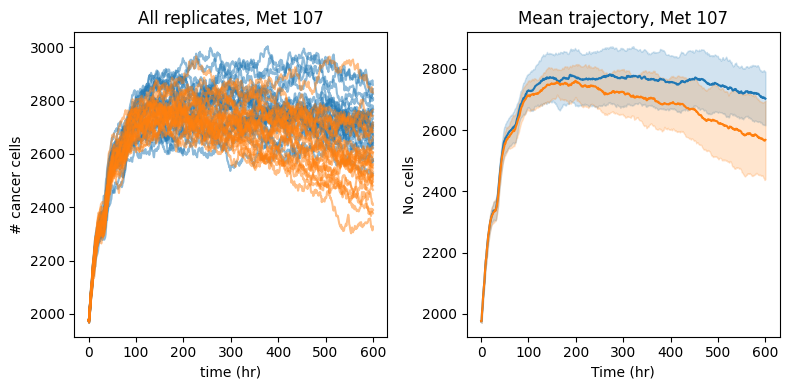

In [3]:
# We can then, for example, plot the cancer time series data for all replicates
fig, ax = plt.subplots(1, 2, figsize=(8, 4), dpi=100)

# Here, we can use the DF directly to plot each replicate's TS data
met_notx["c"].plot(legend=False, ax=ax[0], color='tab:blue', alpha=0.5)
met_tx["c"].plot(legend=False, ax=ax[0], color='tab:orange', alpha=0.5)
ax[0].set(xlabel="time (hr)", ylabel="# cancer cells", title=f"All replicates, Met {met}")

# We can also use our visualization built-in functions to plot this with some processing
# This allows us to see the avg +/- one standard deviation
plot_ts(met_notx, types_to_plot=["c"], title=f"Mean trajectory, Met {met}", ax=ax[1])
plot_ts(met_tx, types_to_plot=["c"], title=f"Mean trajectory, Met {met}", ax=ax[1])

fig.tight_layout()

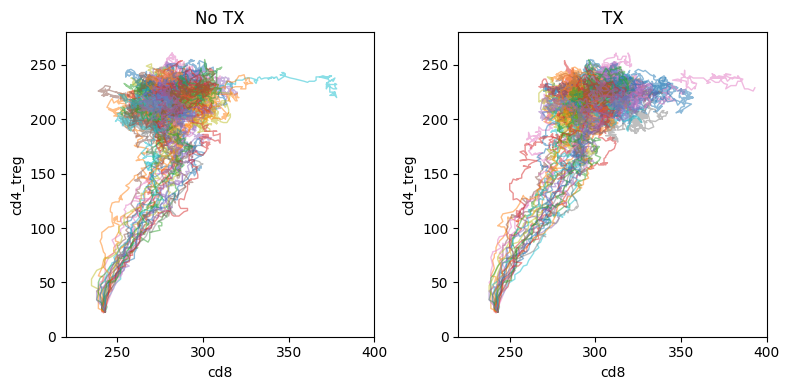

In [4]:
# We can also use the DFs directly to make other plots
# For example, we can look at the phase-space trajectories in terms of two cell populations

ctype1 = "cd8"
ctype2 = "cd4_treg"

xlim = [220, 400]
ylim = [0, 280]

fig, ax = plt.subplots(1, 2, figsize=(8, 4), dpi=100)
for i in range(25):
    ax[0].plot(met_notx[ctype1][str(i)], met_notx[ctype2][str(i)], lw=1, alpha=0.5)
    ax[1].plot(met_tx[ctype1][str(i)], met_notx[ctype2][str(i)], lw=1, alpha=0.5)

ax[0].set(xlabel=ctype1, ylabel=ctype2, title="No TX", xlim=xlim, ylim=ylim)
ax[1].set(xlabel=ctype1, ylabel=ctype2, title="TX", xlim=xlim, ylim=ylim)

fig.tight_layout()

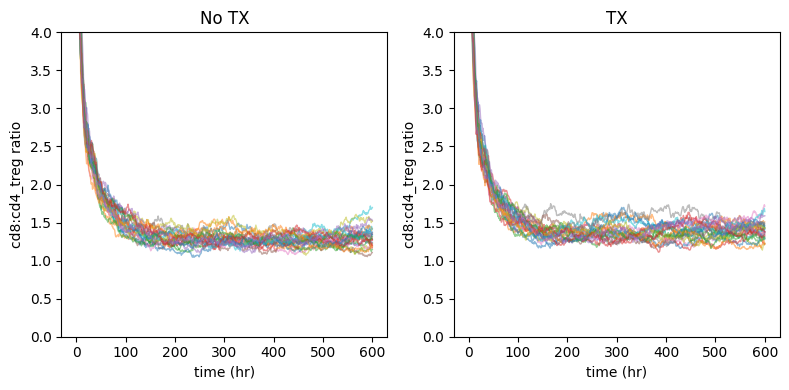

In [5]:
# Or we could consider their ratio over time

fig, ax = plt.subplots(1, 2, figsize=(8, 4), dpi=100)
for i in range(25):
    ax[0].plot(met_notx[ctype1][str(i)] / met_notx[ctype2][str(i)], lw=1, alpha=0.5)
    ax[1].plot(met_tx[ctype1][str(i)] / met_notx[ctype2][str(i)], lw=1, alpha=0.5)

ax[0].set(xlabel="time (hr)", ylabel=f"{ctype1}:{ctype2} ratio", title="No TX", ylim=(0, 4))
ax[1].set(xlabel="time (hr)", ylabel=f"{ctype1}:{ctype2} ratio", title="TX", ylim=(0, 4))

fig.tight_layout()

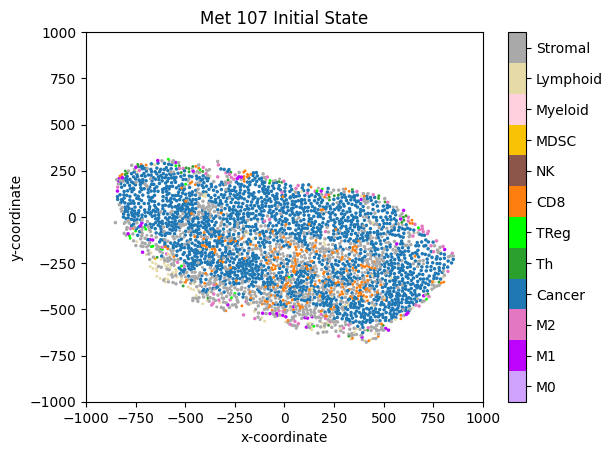

In [6]:
# If we wanted to see what the met looks like initially, then we can also plot this
met_ic = os.path.join(path_notx, "set_0", "cellLists", "day_0", "cells.csv")
fig = plot_celldata(met_ic, title=f"Met {met} Initial State")
fig.set_dpi(100) # Default is 300 DPI

## Examining metastases with divergent behaviours

For some of our mets, we can observe different categories of behaviours regardless of treatment. This is unlike what we see above for Met 107, where the replicates seem to follow a normal distribution (when we slice at a single timepoint). Here, we will look at **Met 106**, for which we have run 100 replicates, rather than 25.

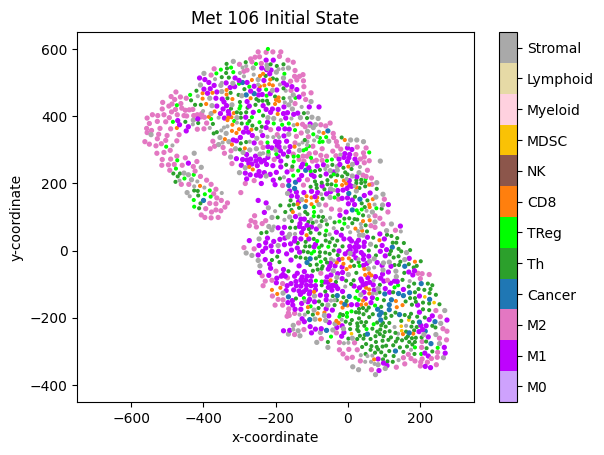

In [7]:
# Load data for Met 106
met = 106
path_notx = os.path.join(path_to_simulations, "simulations_may2026", f"mIHC_{met}")
path_tx = os.path.join(path_to_simulations, "simulations_may2026", f"mIHC_{met}_tx")
met_notx = retrieve_ts(path_notx, num_replicates=100)
met_tx = retrieve_ts(path_tx, num_replicates=100)

# Visualize
met_ic = os.path.join(path_notx, "set_0", "cellLists", "day_0", "cells.csv")
fig = plot_celldata(met_ic, title=f"Met {met} Initial State", xmin=-750, xmax=350, ymin=-450, ymax=650)
fig.set_dpi(100) 

/tmp/SLURM_4167266/ipykernel_1083657/4024987708.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pop_i = met_notx["c"].iloc[0][0]


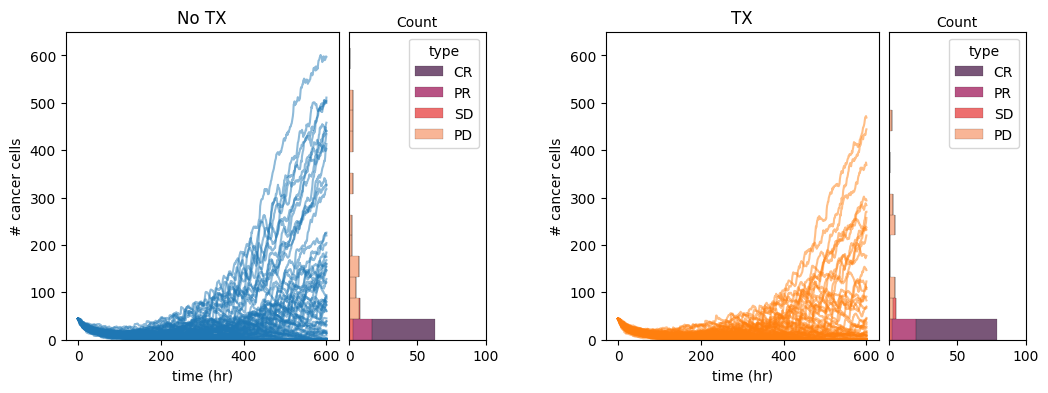

In [8]:
# Let's visualize the trajectories; here, we also look at different end-state categories
import matplotlib.gridspec as gridspec

# Create the figure and create a grid for the figure,
fig = plt.figure(figsize=(12, 4), dpi=100)
grid_l = gridspec.GridSpec(1, 2, left=0.1, right=0.45, wspace=0.05, width_ratios=[2,1])
grid_r = gridspec.GridSpec(1, 2, left=0.55, right=0.9, wspace=0.05, width_ratios=[2,1])
ax00 = fig.add_subplot(grid_l[0,0])
ax01 = fig.add_subplot(grid_l[0,1])
ax02 = fig.add_subplot(grid_r[0,0])
ax03 = fig.add_subplot(grid_r[0,1])
max_y = 650

# Visualize the trajectories
met_notx["c"].plot(legend=False, ax=ax00, color='tab:blue', alpha=0.5)
ax00.set(xlabel="time (hr)", ylabel="# cancer cells", title="No TX", ylim=[0, max_y])

met_tx["c"].plot(legend=False, ax=ax02, color='tab:orange', alpha=0.5)
ax02.set(xlabel="time (hr)", ylabel="# cancer cells", title="TX", ylim=[0, max_y])

# Bin the trajectories into pre-defined categories and add as a histogram
pop_i = met_notx["c"].iloc[0][0]
notx_intervals = pd.cut(met_notx["c"].iloc[600], bins=[-1, 0, 0.7*pop_i, 1.2*pop_i, 15*pop_i], labels=['CR', 'PR', 'SD', 'PD'], right=True)
tx_intervals = pd.cut(met_tx["c"].iloc[600], bins=[-1, 0, 0.7*pop_i, 1.2*pop_i, 15*pop_i], labels=['CR', 'PR', 'SD', 'PD'], right=True)

kwargs = {"y":"pop", "binwidth":1*pop_i, "binrange":(0, 15*pop_i), "multiple":"stack", "legend":True, "palette":"rocket", "hue":"type", "lw":.1}
df = pd.DataFrame({'pop' : met_notx["c"].iloc[600], 'type' : notx_intervals})
sns.histplot(df, ax=ax01, **kwargs)
df = pd.DataFrame({'pop' : met_tx["c"].iloc[600], 'type' : tx_intervals})
sns.histplot(df, ax=ax03, **kwargs)

for ax in [ax01, ax03]:
    ax.set(ylabel="", xlim=(0, 100), ylim=(0, max_y))
    ax.get_yaxis().set_visible(False)
    ax.xaxis.set_label_position('top') 

If we focus on the no treatment trajectories for a moment, we can see that there are a large number that are classified as partial (PR) or complete response (CR), meaning that the metastasis is shrinking. However, we can also see a number of stable disease (SD) replicates, and a few progressive disease (PD) replicates that have varied final cancer counts. Looking more closely at the PD replicates, we see that there is a group which grows quickly (and end w/ +300 cells) and a group which grows more slowly.

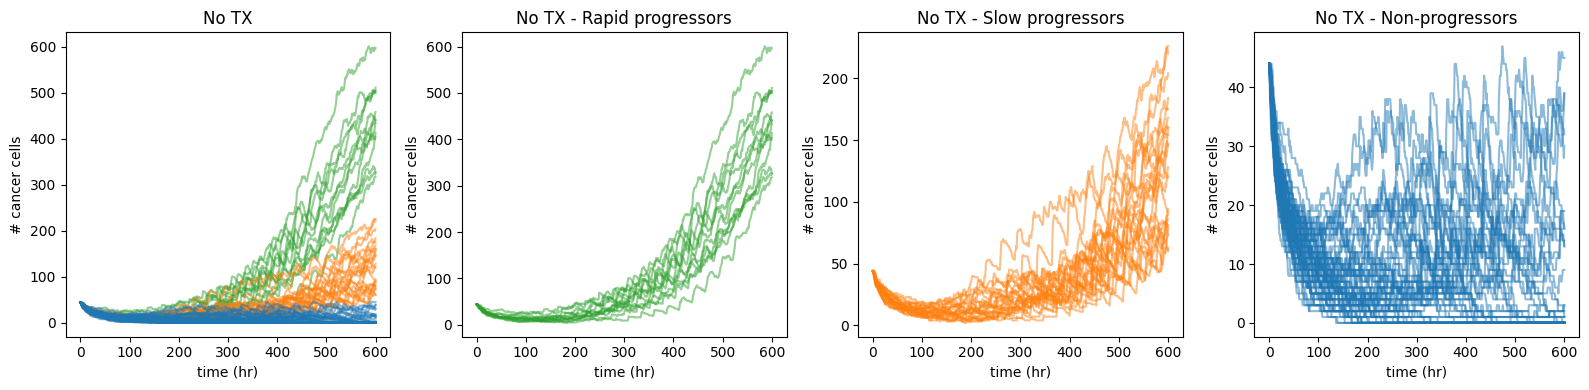

In [9]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4), dpi=100)

# Get rapid progressors
dft = met_notx["c"].T
dft = dft[dft[600] >= 300]
rapid_notx = dft.T
rapid_notx.plot(legend=False, ax=ax[0], color='tab:green', alpha=0.5)
rapid_notx.plot(legend=False, ax=ax[1], color='tab:green', alpha=0.5)

# Get slow progressors
dft = met_notx["c"].T
dft = dft[dft[600] >= pop_i*1.2]
dft = dft[dft[600] < 300]
slow_notx = dft.T
slow_notx.plot(legend=False, ax=ax[0], color='tab:orange', alpha=0.5)
slow_notx.plot(legend=False, ax=ax[2], color='tab:orange', alpha=0.5)

# Get non-progressors
dft = met_notx["c"].T
dft = dft[dft[600] < pop_i*1.2]
nonprog_notx = dft.T
nonprog_notx.plot(legend=False, ax=ax[0], color='tab:blue', alpha=0.5)
nonprog_notx.plot(legend=False, ax=ax[3], color='tab:blue', alpha=0.5)

ax[0].set(xlabel="time (hr)", ylabel="# cancer cells", title="No TX")
ax[1].set(xlabel="time (hr)", ylabel="# cancer cells", title="No TX - Rapid progressors")
ax[2].set(xlabel="time (hr)", ylabel="# cancer cells", title="No TX - Slow progressors")
ax[3].set(xlabel="time (hr)", ylabel="# cancer cells", title="No TX - Non-progressors")

fig.tight_layout()

We can use the replicate indicies we obtain above in order to visualize other features of the different groupings. For example, we could look at the number of CD8+ T cells, the ratio of CD8+ T cells to cancer cells, or the ratio of CD8+ T cells to Tregs.

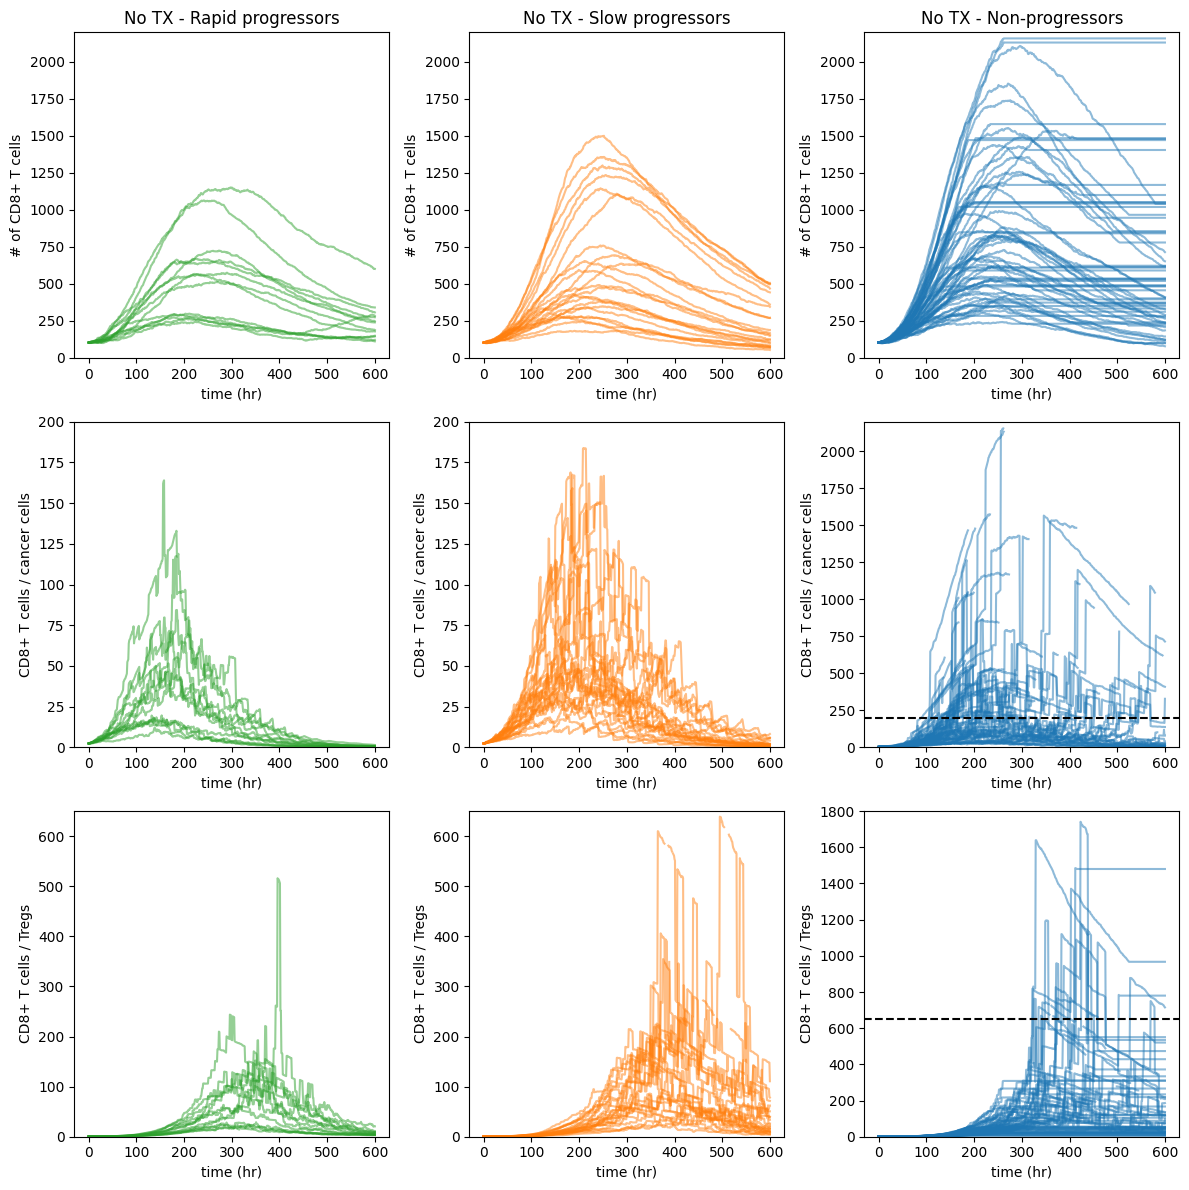

In [11]:
fig, ax = plt.subplots(3, 3, figsize=(12, 12), dpi=100)

# CD8+ T cell populations
met_notx["cd8"][rapid_notx.columns].plot(ax=ax[0,0], legend=False, color="tab:green", alpha=0.5)
met_notx["cd8"][slow_notx.columns].plot(ax=ax[0,1], legend=False, color="tab:orange", alpha=0.5)
met_notx["cd8"][nonprog_notx.columns].plot(ax=ax[0,2], legend=False, color="tab:blue", alpha=0.5)

titles = ["No TX - Rapid progressors", "No TX - Slow progressors", "No TX - Non-progressors"]
for i, axis in enumerate([ax[0,0], ax[0,1], ax[0,2]]):
    axis.set(xlabel="time (hr)", ylabel="# of CD8+ T cells", title=titles[i], ylim=[0, 2200])

# CD8+ T cell / cancer cell ratios
(met_notx["cd8"][rapid_notx.columns] / met_notx["c"][rapid_notx.columns]).plot(ax=ax[1,0], legend=False, color="tab:green", alpha=0.5) 
(met_notx["cd8"][slow_notx.columns] / met_notx["c"][slow_notx.columns]).plot(ax=ax[1,1], legend=False, color="tab:orange", alpha=0.5)
(met_notx["cd8"][nonprog_notx.columns] / met_notx["c"][nonprog_notx.columns]).plot(ax=ax[1,2], legend=False, color="tab:blue", alpha=0.5)
for i, axis in enumerate([ax[1,0], ax[1,1], ax[1,2]]):
    axis.set(xlabel="time (hr)", ylabel="CD8+ T cells / cancer cells", ylim=[0, 200])
ax[1,2].set(ylim=[0, 2200])
ax[1,2].axhline(200, ls='--', color='k')

# CD8+ T cell / Treg ratios
(met_notx["cd8"][rapid_notx.columns] / met_notx["cd4_treg"][rapid_notx.columns]).plot(ax=ax[2,0], legend=False, color="tab:green", alpha=0.5) 
(met_notx["cd8"][slow_notx.columns] / met_notx["cd4_treg"][slow_notx.columns]).plot(ax=ax[2,1], legend=False, color="tab:orange", alpha=0.5)
(met_notx["cd8"][nonprog_notx.columns] / met_notx["cd4_treg"][nonprog_notx.columns]).plot(ax=ax[2,2], legend=False, color="tab:blue", alpha=0.5)
for i, axis in enumerate([ax[2,0], ax[2,1], ax[2,2]]):
    axis.set(xlabel="time (hr)", ylabel="CD8+ T cells / Tregs", ylim=[0, 650])
ax[2,2].set(ylim=[0, 1800])
ax[2,2].axhline(650, ls='--', color='k')

fig.tight_layout()

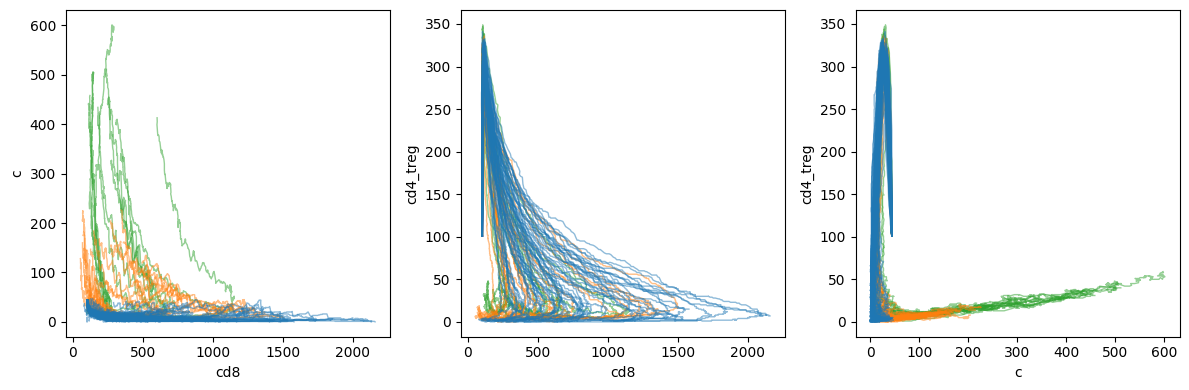

In [24]:
# We can also visualize the ratio-trajectories in phase-space

ctype1 = "cd8"
ctype2 = "c"
ctype3 = "cd4_treg"

fig, ax = plt.subplots(1, 3, figsize=(12, 4), dpi=100)
for i in rapid_notx.columns:
    ax[0].plot(met_notx[ctype1][rapid_notx.columns][str(i)], met_notx[ctype2][rapid_notx.columns][str(i)], lw=1, alpha=0.5, color="tab:green")
    ax[1].plot(met_notx[ctype1][rapid_notx.columns][str(i)], met_notx[ctype3][rapid_notx.columns][str(i)], lw=1, alpha=0.5, color="tab:green")
    ax[2].plot(met_notx[ctype2][rapid_notx.columns][str(i)], met_notx[ctype3][rapid_notx.columns][str(i)], lw=1, alpha=0.5, color="tab:green")
for i in slow_notx.columns:
    ax[0].plot(met_notx[ctype1][slow_notx.columns][str(i)], met_notx[ctype2][slow_notx.columns][str(i)], lw=1, alpha=0.5, color="tab:orange")
    ax[1].plot(met_notx[ctype1][slow_notx.columns][str(i)], met_notx[ctype3][slow_notx.columns][str(i)], lw=1, alpha=0.5, color="tab:orange")
    ax[2].plot(met_notx[ctype2][slow_notx.columns][str(i)], met_notx[ctype3][slow_notx.columns][str(i)], lw=1, alpha=0.5, color="tab:orange")
for i in nonprog_notx.columns:
    ax[0].plot(met_notx[ctype1][nonprog_notx.columns][str(i)], met_notx[ctype2][nonprog_notx.columns][str(i)], lw=1, alpha=0.5, color="tab:blue")
    ax[1].plot(met_notx[ctype1][nonprog_notx.columns][str(i)], met_notx[ctype3][nonprog_notx.columns][str(i)], lw=1, alpha=0.5, color="tab:blue")
    ax[2].plot(met_notx[ctype2][nonprog_notx.columns][str(i)], met_notx[ctype3][nonprog_notx.columns][str(i)], lw=1, alpha=0.5, color="tab:blue")


ax[0].set(xlabel=ctype1, ylabel=ctype2)
ax[1].set(xlabel=ctype1, ylabel=ctype3)
ax[2].set(xlabel=ctype2, ylabel=ctype3)

fig.tight_layout()

As before, we can easily change what we're looking at by changing the three cell types specified above -- for example, mets look at how the three macrophage populations change relative to one another over time, which can give us a sense of the pro- or anti-tumor state of the TME!

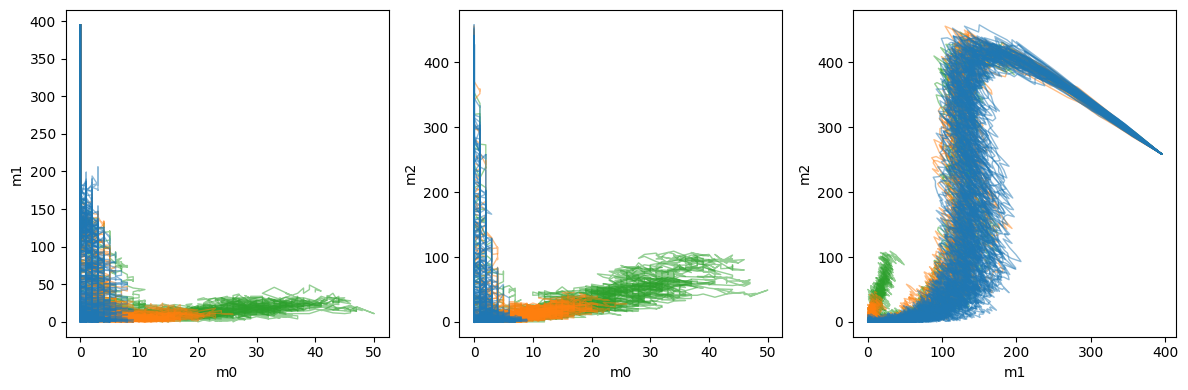

In [40]:
ctype1 = "m0"
ctype2 = "m1"
ctype3 = "m2"

fig, ax = plt.subplots(1, 3, figsize=(12, 4), dpi=100)
for i in rapid_notx.columns:
    ax[0].plot(met_notx[ctype1][str(i)], met_notx[ctype2][str(i)], lw=1, alpha=0.5, color="tab:green")
    ax[1].plot(met_notx[ctype1][str(i)], met_notx[ctype3][str(i)], lw=1, alpha=0.5, color="tab:green")
    ax[2].plot(met_notx[ctype2][str(i)], met_notx[ctype3][str(i)], lw=1, alpha=0.5, color="tab:green")
for i in slow_notx.columns:
    ax[0].plot(met_notx[ctype1][str(i)], met_notx[ctype2][str(i)], lw=1, alpha=0.5, color="tab:orange")
    ax[1].plot(met_notx[ctype1][str(i)], met_notx[ctype3][str(i)], lw=1, alpha=0.5, color="tab:orange")
    ax[2].plot(met_notx[ctype2][str(i)], met_notx[ctype3][str(i)], lw=1, alpha=0.5, color="tab:orange")
for i in nonprog_notx.columns:
    ax[0].plot(met_notx[ctype1][str(i)], met_notx[ctype2][str(i)], lw=1, alpha=0.5, color="tab:blue")
    ax[1].plot(met_notx[ctype1][str(i)], met_notx[ctype3][str(i)], lw=1, alpha=0.5, color="tab:blue")
    ax[2].plot(met_notx[ctype2][str(i)], met_notx[ctype3][str(i)], lw=1, alpha=0.5, color="tab:blue")


ax[0].set(xlabel=ctype1, ylabel=ctype2)
ax[1].set(xlabel=ctype1, ylabel=ctype3)
ax[2].set(xlabel=ctype2, ylabel=ctype3)

fig.tight_layout()